# Machine Learning Assignment 2 — Breast Cancer Wisconsin

**Student:** Sangam Samdarshi  
**BITS ID:** 2025AC05127  
**Problem type:** Binary classification  
**Positive class:** Malignant (`M`)

This notebook documents the complete experiment and uses the same training functions that generate the model files loaded by the Streamlit application.

## 1. Import libraries and locate the project

In [1]:
from pathlib import Path
import json
import sys

import joblib
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display
from sklearn.metrics import ConfusionMatrixDisplay, classification_report

ROOT = Path.cwd()
if ROOT.name == "analysis":
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

from model.train_diagnosis_models import (
    MODEL_FILENAMES,
    TARGET,
    build_artifacts,
    load_dataset,
    model_set,
)

print("Project folder:", ROOT.name)

Project folder: sangam_breast_cancer_assignment


## 2. Inspect the uploaded raw CSV

In [2]:
raw_df = pd.read_csv(ROOT / "dataset" / "breast_cancer_wisconsin.csv")
print("Raw shape:", raw_df.shape)
print("Duplicate rows:", raw_df.duplicated().sum())
print("Completely empty columns:", raw_df.columns[raw_df.isna().all()].tolist())
display(raw_df.head())

Raw shape: (569, 33)
Duplicate rows: 0
Completely empty columns: ['Unnamed: 32']


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,radius_se,texture_se,perimeter_se,area_se,smoothness_se,compactness_se,concavity_se,concave points_se,symmetry_se,fractal_dimension_se,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,1.0950,0.9053,8.589,153.40,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,0.7456,0.7869,4.585,94.03,0.006150,0.04006,0.03832,0.02058,0.02250,0.004571,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,0.4956,1.1560,3.445,27.23,0.009110,0.07458,0.05661,0.01867,0.05963,0.009208,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,0.7572,0.7813,5.438,94.44,0.011490,0.02461,0.05688,0.01885,0.01756,0.005115,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


The raw file contains 569 records and 33 columns. `id` is an identifier rather than a diagnostic measurement, and `Unnamed: 32` is completely empty. Both are removed before modelling. The remaining 30 predictors are numeric measurements derived from digitized images of cell nuclei.

## 3. Clean features and encode the target

In [3]:
X, y = load_dataset()
print("Feature matrix shape:", X.shape)
print("Missing numeric values:", int(X.isna().sum().sum()))
print("Target encoding: B -> 0, M -> 1")
display(pd.DataFrame({
    "encoded_value": [0, 1],
    "label": ["Benign", "Malignant"],
    "records": [int((y == 0).sum()), int((y == 1).sum())],
}))

Feature matrix shape: (569, 30)
Missing numeric values: 0
Target encoding: B -> 0, M -> 1


,encoded_value,label,records
0,0,Benign,357
1,1,Malignant,212


The split is stratified so the benign/malignant ratio is preserved. Median imputation is kept inside every pipeline. Scaling is used for Logistic Regression, kNN, and Gaussian Naive Bayes; the tree models do not require it.

## 4. Review the model definitions

In [4]:
for name, pipeline in model_set().items():
    print(f"\n{name}")
    print(pipeline)


Logistic Regression
Pipeline(steps=[('simpleimputer', SimpleImputer(strategy='median')),
                ('standardscaler', StandardScaler()),
                ('logisticregression',
                 LogisticRegression(class_weight='balanced', max_iter=5000,
                                    random_state=17))])

Decision Tree
Pipeline(steps=[('simpleimputer', SimpleImputer(strategy='median')),
                ('decisiontreeclassifier',
                 DecisionTreeClassifier(class_weight='balanced', max_depth=4,
                                        min_samples_leaf=4, random_state=17))])

kNN
Pipeline(steps=[('simpleimputer', SimpleImputer(strategy='median')),
                ('standardscaler', StandardScaler()),
                ('kneighborsclassifier',
                 KNeighborsClassifier(n_neighbors=7, weights='distance'))])

Naive Bayes
Pipeline(steps=[('simpleimputer', SimpleImputer(strategy='median')),
                ('standardscaler', StandardScaler()),
                ('g

## 5. Train all models and save deployment artifacts

In [5]:
summary = build_artifacts()
results = pd.DataFrame(summary["models"]["results"])
display(results.round(4))


Breast cancer models trained successfully.

              Model  Accuracy    AUC  Precision  Recall     F1    MCC
Logistic Regression    0.9737 0.9974     0.9535  0.9762 0.9647 0.9439
      Decision Tree    0.9386 0.9668     0.9070  0.9286 0.9176 0.8689
                kNN    0.9737 0.9787     1.0000  0.9286 0.9630 0.9442
        Naive Bayes    0.9474 0.9927     0.9500  0.9048 0.9268 0.8864
      Random Forest    0.9561 0.9944     0.9512  0.9286 0.9398 0.9054

Saved labelled test data: test_data.csv
Saved model files directly under: model


,Model,Accuracy,AUC,Precision,Recall,F1,MCC
0,Logistic Regression,0.9737,0.9974,0.9535,0.9762,0.9647,0.9439
1,Decision Tree,0.9386,0.9668,0.9070,0.9286,0.9176,0.8689
2,kNN,0.9737,0.9787,1.0000,0.9286,0.9630,0.9442
3,Naive Bayes,0.9474,0.9927,0.9500,0.9048,0.9268,0.8864
4,Random Forest,0.9561,0.9944,0.9512,0.9286,0.9398,0.9054


The script creates one stratified 80/20 split using random state 17. It fits every model only on the 455 training records and exports the untouched 114 test records as `test_data.csv`. Each Joblib file stores the entire preprocessing-and-classifier pipeline.

## 6. Examine the selected overall model

In [6]:
test_df = pd.read_csv(ROOT / "test_data.csv")
feature_names = summary["dataset"]["features"]
X_test = test_df[feature_names]
y_test = test_df[TARGET].map({"B": 0, "M": 1})

selected_name = "Logistic Regression"
selected_model = joblib.load(ROOT / "model" / MODEL_FILENAMES[selected_name])
prediction = selected_model.predict(X_test)

print(classification_report(
    y_test,
    prediction,
    labels=[0, 1],
    target_names=["Benign", "Malignant"],
    zero_division=0,
))

              precision    recall  f1-score   support

      Benign       0.99      0.97      0.98        72
   Malignant       0.95      0.98      0.96        42

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



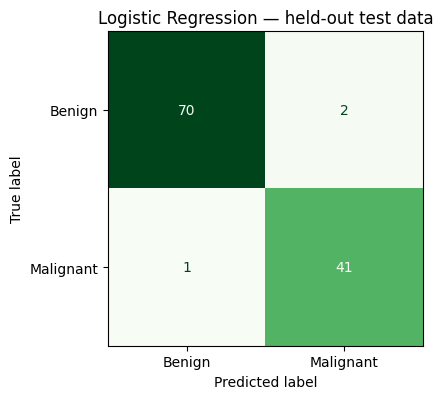

In [7]:
fig, ax = plt.subplots(figsize=(5.4, 4.1))
ConfusionMatrixDisplay.from_predictions(
    y_test,
    prediction,
    labels=[0, 1],
    display_labels=["Benign", "Malignant"],
    cmap="Greens",
    colorbar=False,
    values_format="d",
    ax=ax,
)
ax.set_title("Logistic Regression — held-out test data")
plt.tight_layout()
plt.show()

Logistic Regression is selected as the overall winner because it combines the highest AUC, the highest malignant recall, the highest F1 score, and an MCC above 0.94. kNN has a slightly higher MCC and perfect precision on this split, but it misses more malignant cases and has a lower AUC.

## 7. Confirm the saved files used by Streamlit

In [8]:
artifact_rows = []
for model_name, filename in MODEL_FILENAMES.items():
    path = ROOT / "model" / filename
    artifact_rows.append({
        "model": model_name,
        "file": filename,
        "exists": path.exists(),
        "size_kb": round(path.stat().st_size / 1024, 1),
    })
display(pd.DataFrame(artifact_rows))

,model,file,exists,size_kb
0,Logistic Regression,logistic_regression.joblib,True,2.4
1,Decision Tree,decision_tree.joblib,True,2.4
2,kNN,knn.joblib,True,102.3
3,Naive Bayes,gaussian_naive_bayes.joblib,True,3.0
4,Random Forest,random_forest.joblib,True,305.3


## 8. Execution commands

Rebuild all models and the test file:

```bash
python model/train_diagnosis_models.py
```

Start the web application:

```bash
streamlit run app.py
```

The UI loads the saved pipelines; uploaded CSV files are used only for prediction and evaluation.